<a href="https://colab.research.google.com/github/rakib-alam/comment-collection/blob/main/segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('/content/shopping_trends.csv')

#df.drop('Customer ID', axis=1,inplace=True)
df.head(3)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


Graphs

Gender
Male      2652
Female    1248
Name: count, dtype: int64


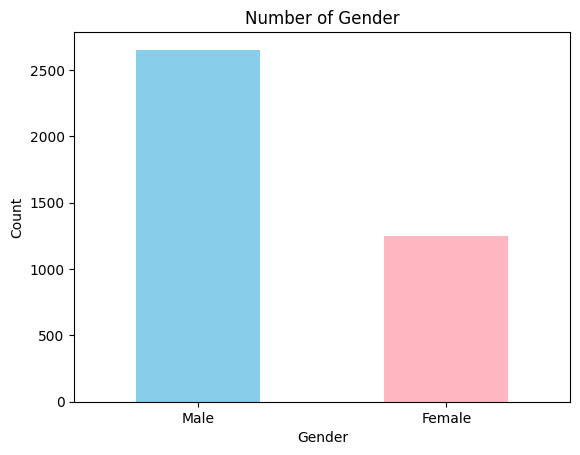

In [ ]:
gender= df['Gender'].value_counts()
print(gender)
gender.plot(kind='bar', color=['skyblue', 'lightpink'])
plt.title('Number of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

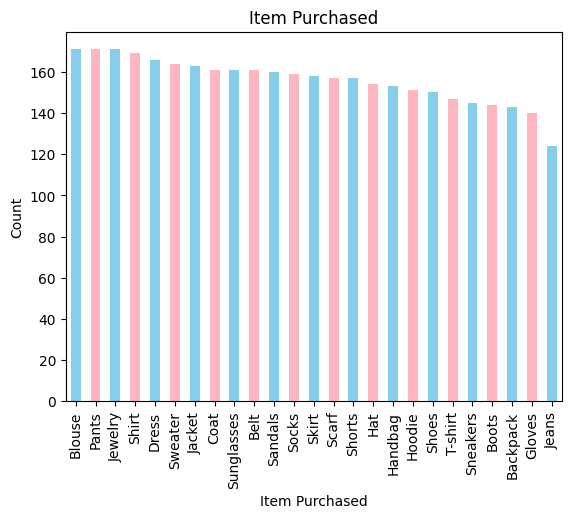

In [ ]:
Category= df['Item Purchased'].value_counts()
Category.plot(kind='bar', color=['skyblue', 'lightpink'])
plt.title('Item Purchased')
plt.xlabel('Item Purchased')
plt.ylabel('Count')

plt.show()

In [ ]:
print(df.columns)

Index(['Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)',
       'Location', 'Size', 'Color', 'Season', 'Review Rating',
       'Subscription Status', 'Payment Method', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Preferred Payment Method', 'Frequency of Purchases'],
      dtype='object')


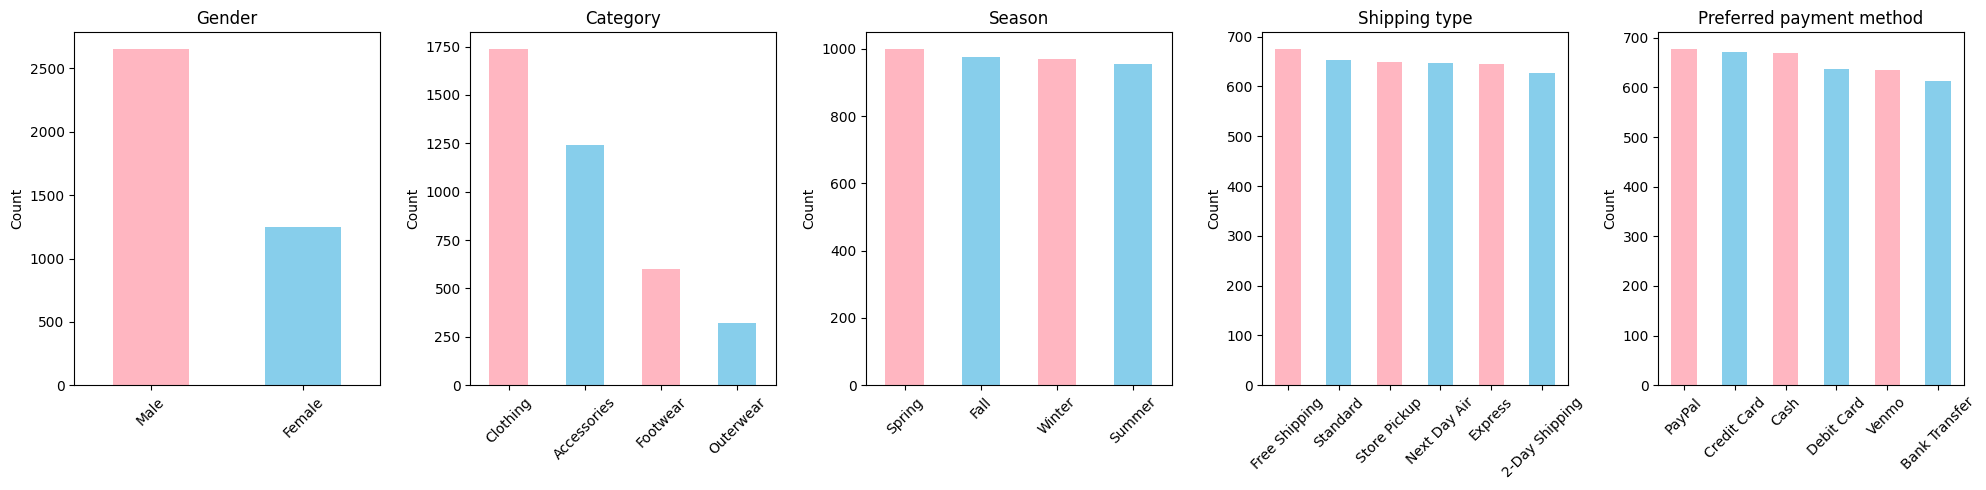

In [ ]:
#categorical variable
categorical_columns = ['Gender', 'Category', 'Season', 'Shipping Type',
                     'Preferred Payment Method']

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))
for i, col in enumerate(categorical_columns):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color=['lightpink','skyblue'])
    axes[i].set_title(col.capitalize())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


bar graph


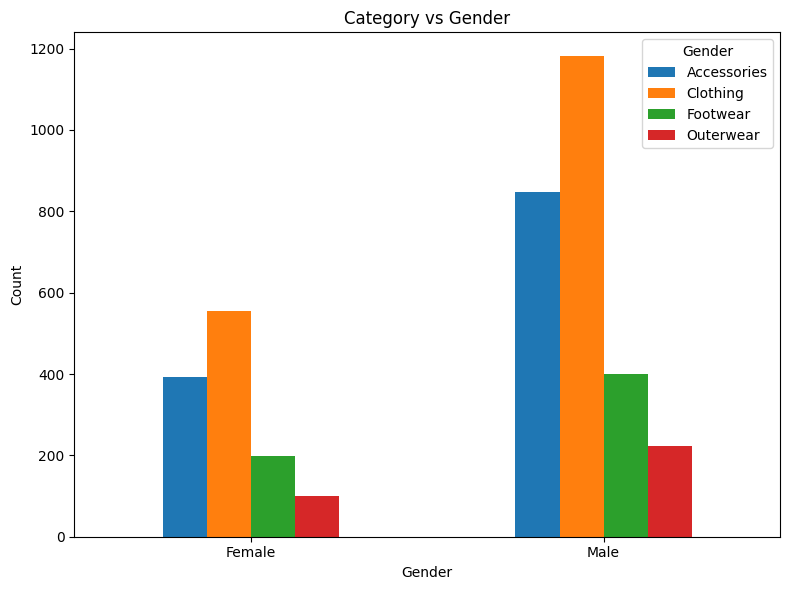

In [ ]:

# frequency
grouped = pd.crosstab(df['Gender'], df['Category'])

# bar chat
grouped.plot(kind='bar', figsize=(8, 6))
plt.title('Category vs Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


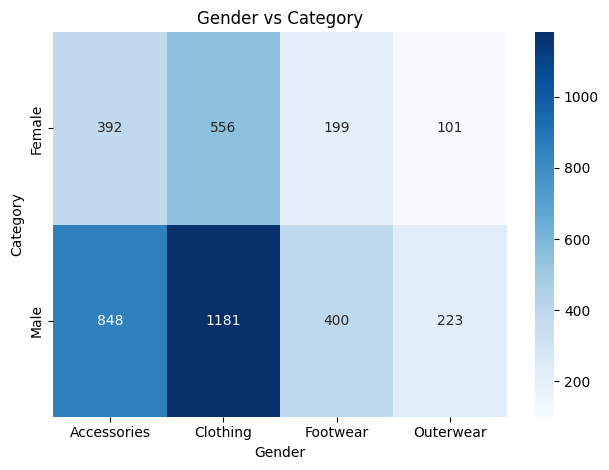

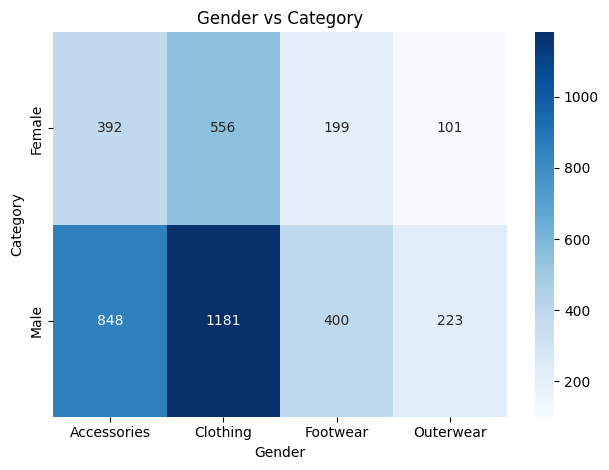

In [ ]:
import seaborn as sns

sns.heatmap(grouped, annot=True, fmt="d", cmap="Blues")
plt.title('Gender vs Category')
plt.xlabel('Gender')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


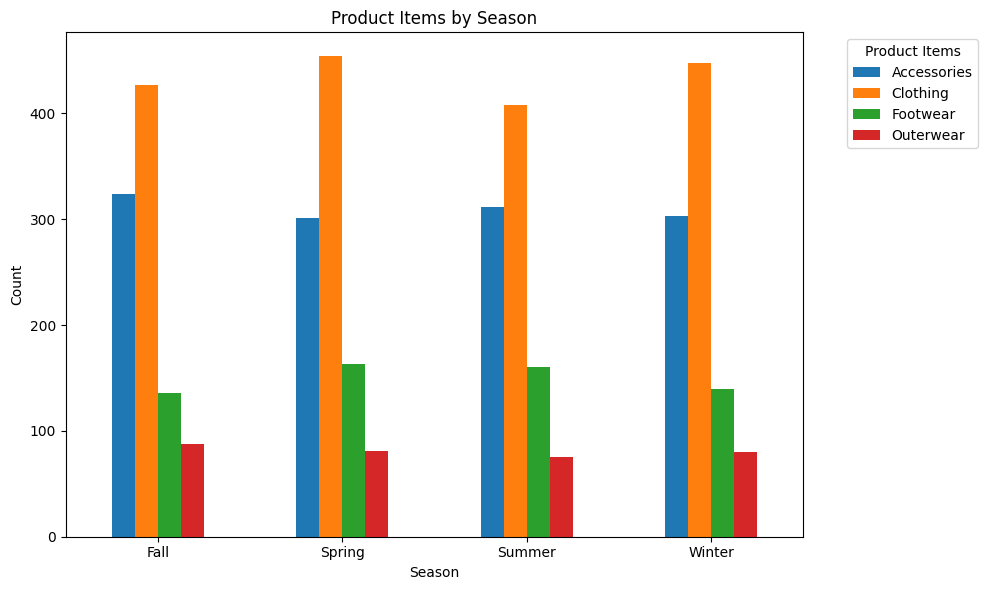

In [ ]:

cross_tab = pd.crosstab(df['Season'], df['Category'])
cross_tab.plot(kind='bar', figsize=(10, 6))
plt.title('Product Items by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.legend(title='Product Items', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

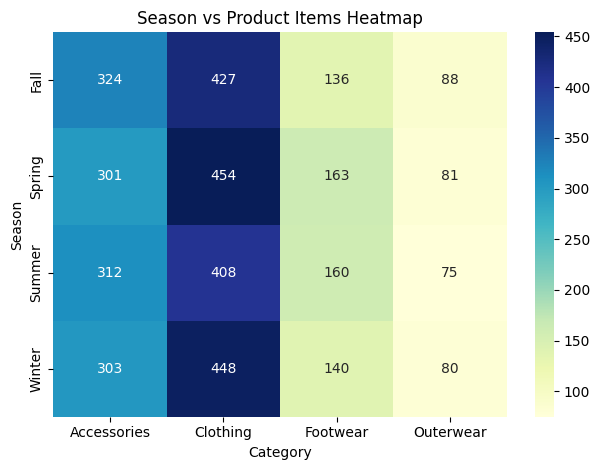

In [ ]:
import seaborn as sns

sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Season vs Product Items Heatmap')
plt.xlabel('Category')
plt.ylabel('Season')
plt.tight_layout()
plt.show()


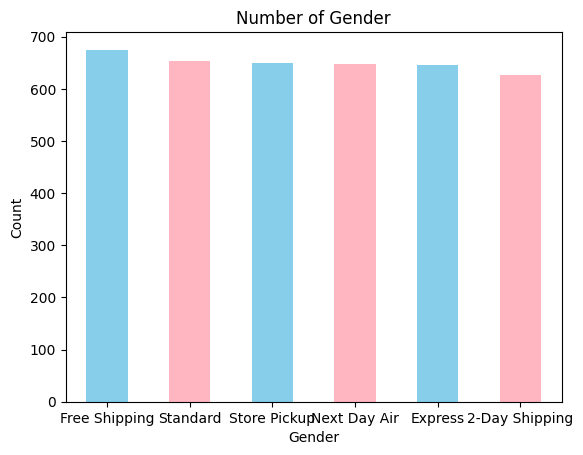

In [ ]:
gender= df['Shipping Type'].value_counts()
gender.plot(kind='bar', color=['skyblue', 'lightpink'])
plt.title('Number of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

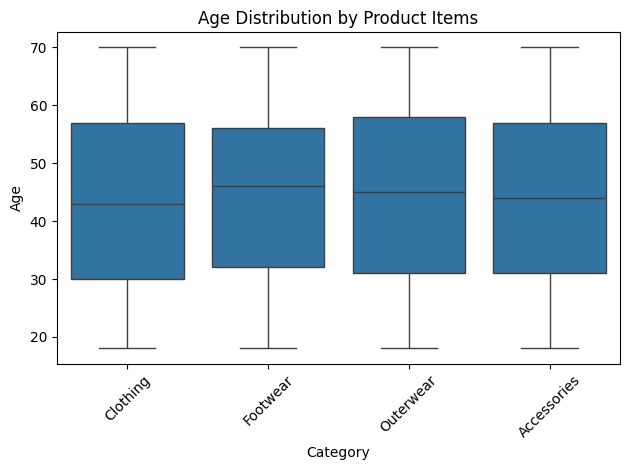

In [ ]:
sns.boxplot(data=df, x='Category', y='Age')
plt.title('Age Distribution by Product Items')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<ipython-input-52-2cbb5dc5653c>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Category', y='Age', inner='quartile', palette='pastel')


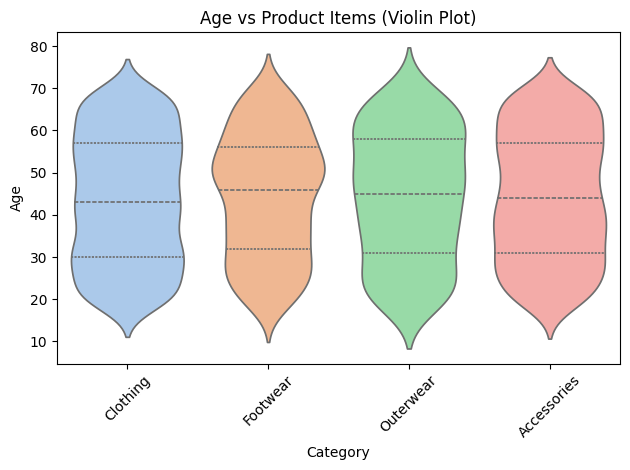

In [ ]:
sns.violinplot(data=df, x='Category', y='Age', inner='quartile', palette='pastel')
plt.title('Age vs Product Items (Violin Plot)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


age vs purchase amout

<Axes: xlabel='Age'>

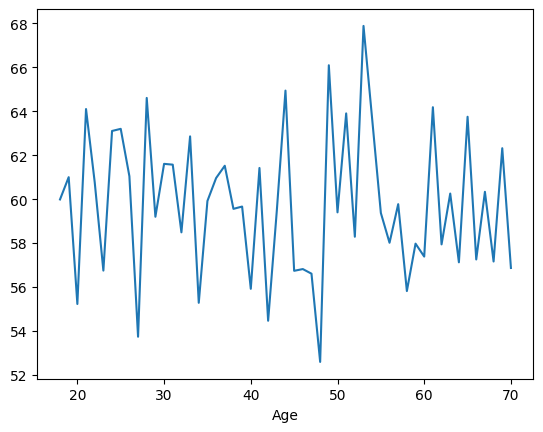

In [ ]:
age_avg = df.groupby('Age')['Purchase Amount (USD)'].mean()
age_avg.plot(kind='line')


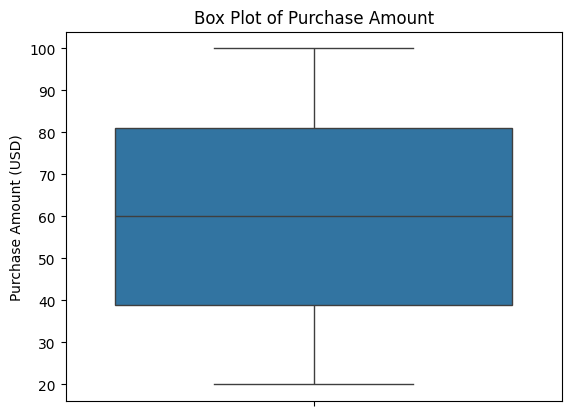

In [ ]:
import seaborn as sns

sns.boxplot(y='Purchase Amount (USD)', data=df)
plt.title('Box Plot of Purchase Amount')
plt.show()


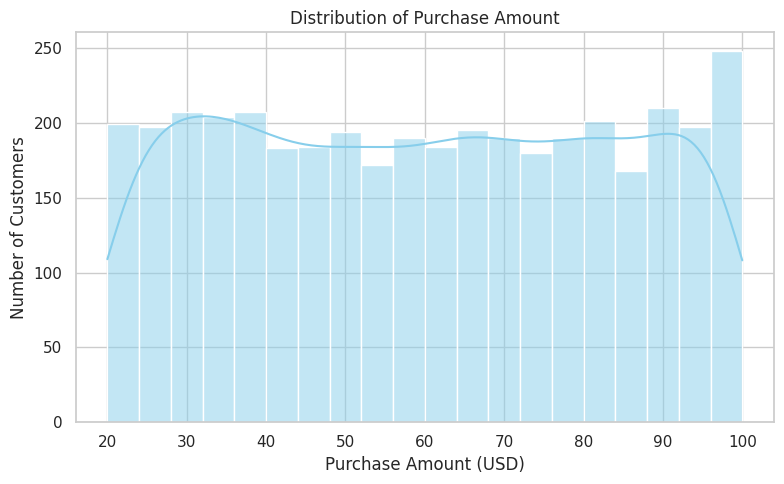

In [ ]:
# Re-import necessary libraries after kernel reset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Plot 1: Distribution of Age
plt.figure(figsize=(8, 5))
sns.histplot(df["Purchase Amount (USD)"], bins=20, kde=True, color="skyblue")
plt.title('Distribution of Purchase Amount')
plt.xlabel("Purchase Amount (USD)")
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


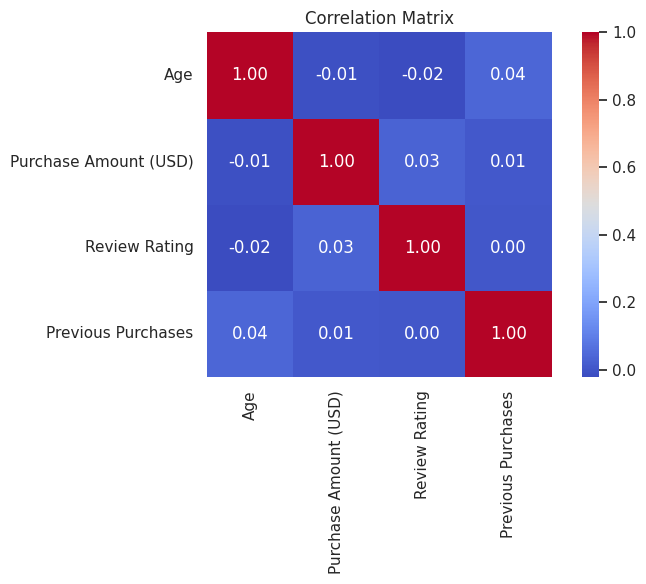

In [ ]:
# Select numeric columns for correlation analysis
numeric_cols = [
    'Age',
    'Purchase Amount (USD)',
    'Review Rating',
    'Previous Purchases'
]

# Compute correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


In [ ]:
# Elbow Method: Determine optimal number of clusters
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'KMeans' is not defined

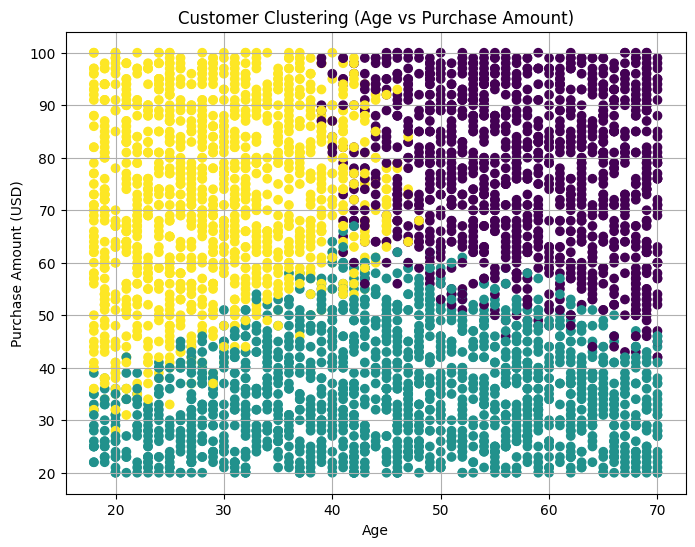

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Step 1: Select numeric columns
features = df[['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']]

# Step 2: Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 3: Apply KMeans (let's use 3 clusters as example)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

# Step 4: Visualize the clusters using Age vs Purchase
plt.figure(figsize=(8, 6))
plt.scatter(df['Age'], df['Purchase Amount (USD)'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Purchase Amount (USD)')
plt.title('Customer Clustering (Age vs Purchase Amount)')
plt.grid(True)
plt.show()


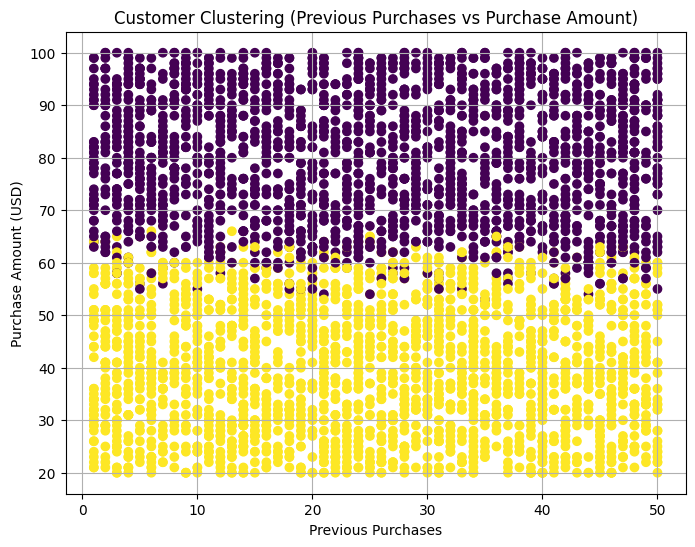

In [ ]:
# Step 4: Visualize the clusters using Age vs Purchase
# Step 3: Apply KMeans (let's use 3 clusters as example)
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)
plt.figure(figsize=(8, 6))
plt.scatter(df['Previous Purchases'], df['Purchase Amount (USD)'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Previous Purchases')
plt.ylabel('Purchase Amount (USD)')
plt.title('Customer Clustering (Previous Purchases vs Purchase Amount)')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
# Using silhouette score to evaluate different numbers of clusters
for n_clusters in range(2, 11):
    clusterer = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = clusterer.fit_predict(scaled_features)
    silhouette_avg = silhouette_score(scaled_features, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette score is: {silhouette_avg}")

For n_clusters = 2, the average silhouette score is: 0.1869461592354748
For n_clusters = 3, the average silhouette score is: 0.17599091873114467
For n_clusters = 4, the average silhouette score is: 0.19359732599753612
For n_clusters = 5, the average silhouette score is: 0.19550255985329934
For n_clusters = 6, the average silhouette score is: 0.19858815057062437
For n_clusters = 7, the average silhouette score is: 0.21088996105050742
For n_clusters = 8, the average silhouette score is: 0.2294551734637747
For n_clusters = 9, the average silhouette score is: 0.2219081805249961
For n_clusters = 10, the average silhouette score is: 0.2185417654063107


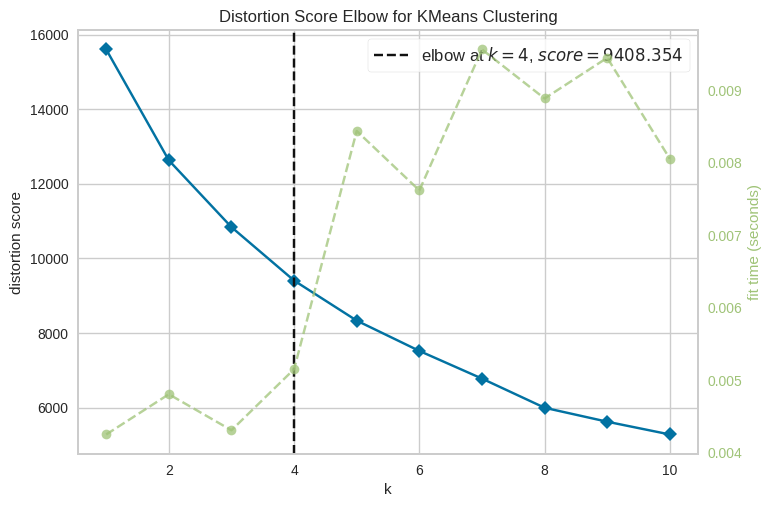

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
# Visualizing the elbow method with Yellowbrick
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(1,11))
visualizer.fit(scaled_features)
visualizer.show()

      Customer ID  Age  Gender Item Purchased     Category  \
0               1   55    Male         Blouse     Clothing   
1               2   19    Male        Sweater     Clothing   
2               3   50    Male          Jeans     Clothing   
3               4   21    Male        Sandals     Footwear   
4               5   45    Male         Blouse     Clothing   
...           ...  ...     ...            ...          ...   
3895         3896   40  Female         Hoodie     Clothing   
3896         3897   52  Female       Backpack  Accessories   
3897         3898   46  Female           Belt  Accessories   
3898         3899   44  Female          Shoes     Footwear   
3899         3900   52  Female        Handbag  Accessories   

      Purchase Amount (USD)       Location Size      Color  Season  \
0                        53       Kentucky    L       Gray  Winter   
1                        64          Maine    L     Maroon  Winter   
2                        73  Massachusetts   

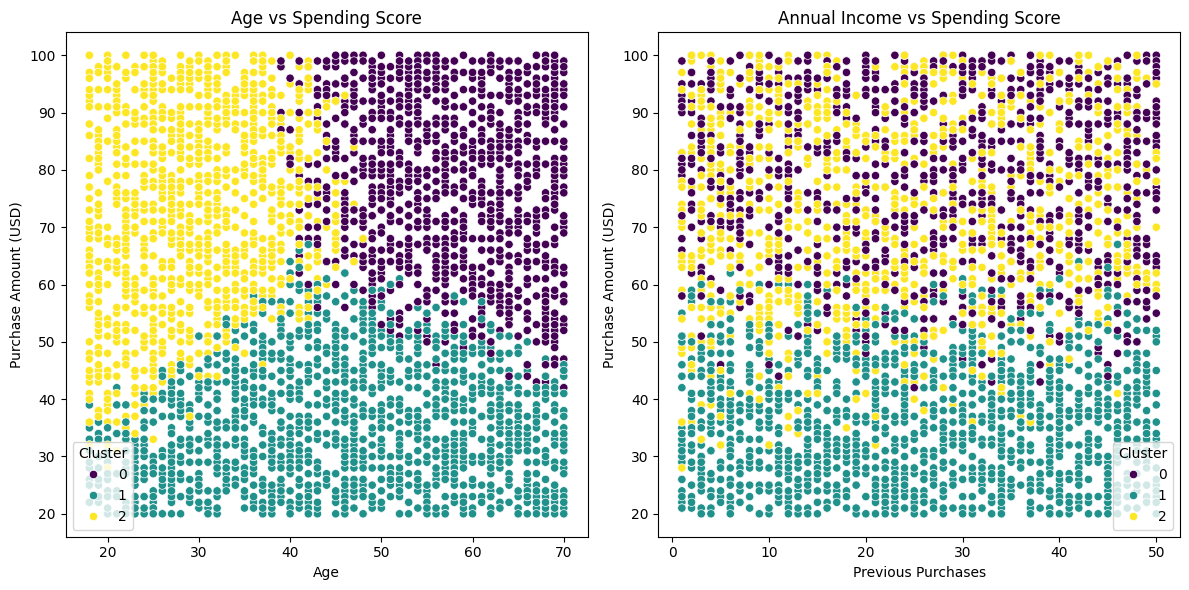

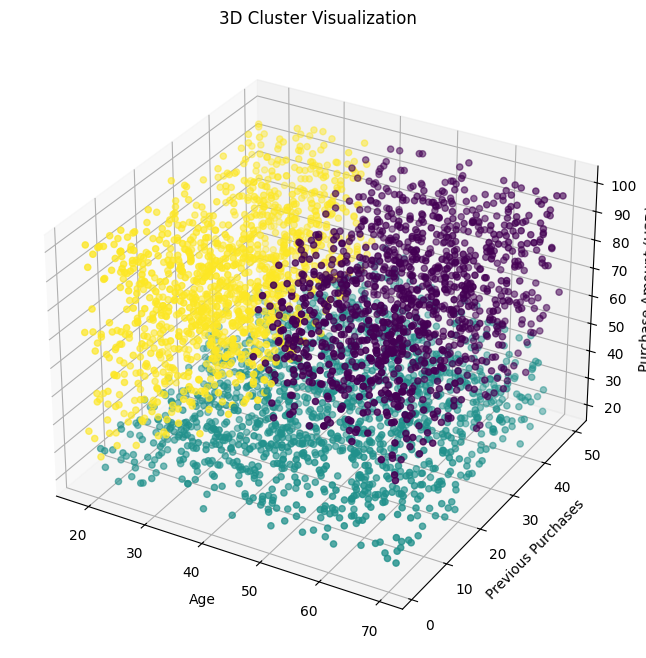

In [ ]:
# Based on the above methods, let's choose 4 clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(scaled_features)

# Add cluster labels to the original dataframe
df['Cluster'] = clusters
print(df)


# Visualize clusters
plt.figure(figsize=(12,6))

# Age vs Spending Score
plt.subplot(1, 2, 1)
sns.scatterplot(x='Age', y='Purchase Amount (USD)', hue='Cluster', data=df, palette='viridis')
plt.title('Age vs Spending Score')

# Annual Income vs Spending Score
plt.subplot(1, 2, 2)
sns.scatterplot(x='Previous Purchases', y='Purchase Amount (USD)', hue='Cluster', data=df, palette='viridis')
plt.title('Annual Income vs Spending Score')

plt.tight_layout()
plt.show()

# 3D visualization
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['Age'], df['Previous Purchases'], df['Purchase Amount (USD)'], c=df['Cluster'], cmap='viridis')
ax.set_xlabel('Age')
ax.set_ylabel('Previous Purchases')
ax.set_zlabel('Purchase Amount (USD)')
plt.title('3D Cluster Visualization')
plt.show()


In [ ]:
print(df.columns)

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases', 'Cluster', 'Segment'],
      dtype='object')


In [ ]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True).round(2)
print("\nCluster Profiles:")
print(cluster_profile)



Cluster Profiles:
         Customer ID    Age  Purchase Amount (USD)  Review Rating  \
Cluster                                                             
0            1948.73  57.25                  77.52           3.85   
1            1946.42  45.91                  35.84           3.63   
2            1957.30  29.24                  72.92           3.80   

         Previous Purchases  
Cluster                      
0                     27.36  
1                     25.63  
2                     23.09  


In [ ]:
# Define the segment names for each cluster
cluster_names = {
    0: "Young Frequent Shoppers",
    1: "Young Occasional Buyers",
    2: "Older High Spenders",
    3: "Older Budget Shoppers"
}

# Map the names to a new column in the DataFrame
df['Segment'] = df['Cluster'].map(cluster_names)

# Display the Customer ID and their assigned Segment
df[['Customer ID', 'Segment']].head(10)


,Customer ID,Segment
0,1,Young Occasional Buyers
1,2,Older High Spenders
2,3,Young Frequent Shoppers
3,4,Older High Spenders
4,5,Young Occasional Buyers
5,6,Young Occasional Buyers
6,7,Young Frequent Shoppers
7,8,Young Occasional Buyers
8,9,Older High Spenders
9,10,Young Occasional Buyers


In [ ]:
cluster_profile = df.groupby('Cluster')[
    ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
].mean().round(2)
print(cluster_profile)


           Age  Purchase Amount (USD)  Review Rating  Previous Purchases
Cluster                                                                 
0        57.25                  77.52           3.85               27.36
1        45.91                  35.84           3.63               25.63
2        29.24                  72.92           3.80               23.09


In [ ]:
cluster_size = df['Cluster'].value_counts().sort_index()
print(cluster_size)


Cluster
0    1156
1    1527
2    1217
Name: count, dtype: int64


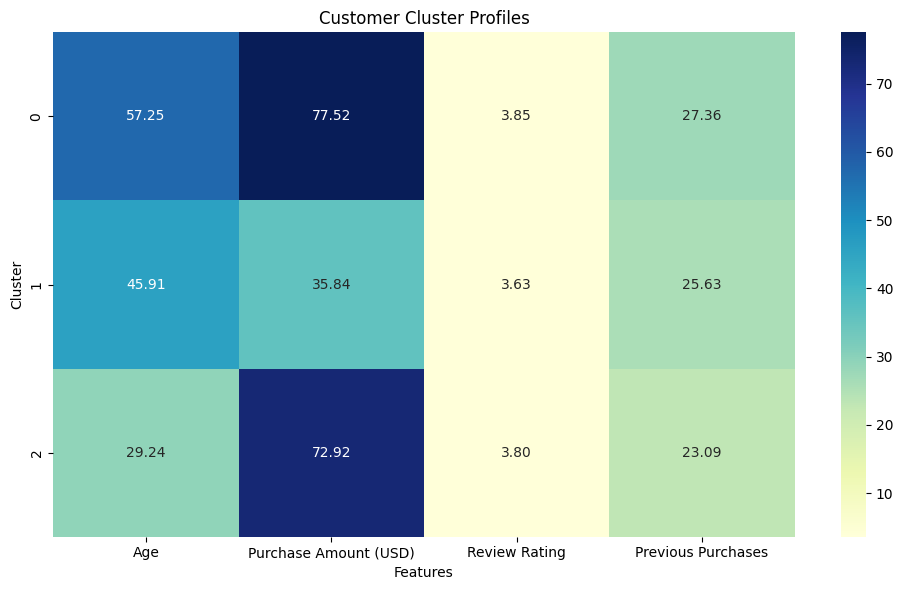

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap to visualize cluster profiles
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Customer Cluster Profiles")
plt.ylabel("Cluster")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


In [ ]:
# Extract Cluster 0
cluster_0 = df[df['Cluster'] == 0]

# Extract Cluster 1
cluster_1 = df[df['Cluster'] == 1]

# Extract Cluster 2
cluster_2 = df[df['Cluster'] == 2]

# Extract Cluster 3
cluster_3 = df[df['Cluster'] == 3]


In [ ]:
cluster_0.to_csv("cluster_0.csv", index=False)
cluster_1.to_csv("cluster_1.csv", index=False)
cluster_2.to_csv("cluster_2.csv", index=False)
cluster_3.to_csv("cluster_3.csv", index=False)


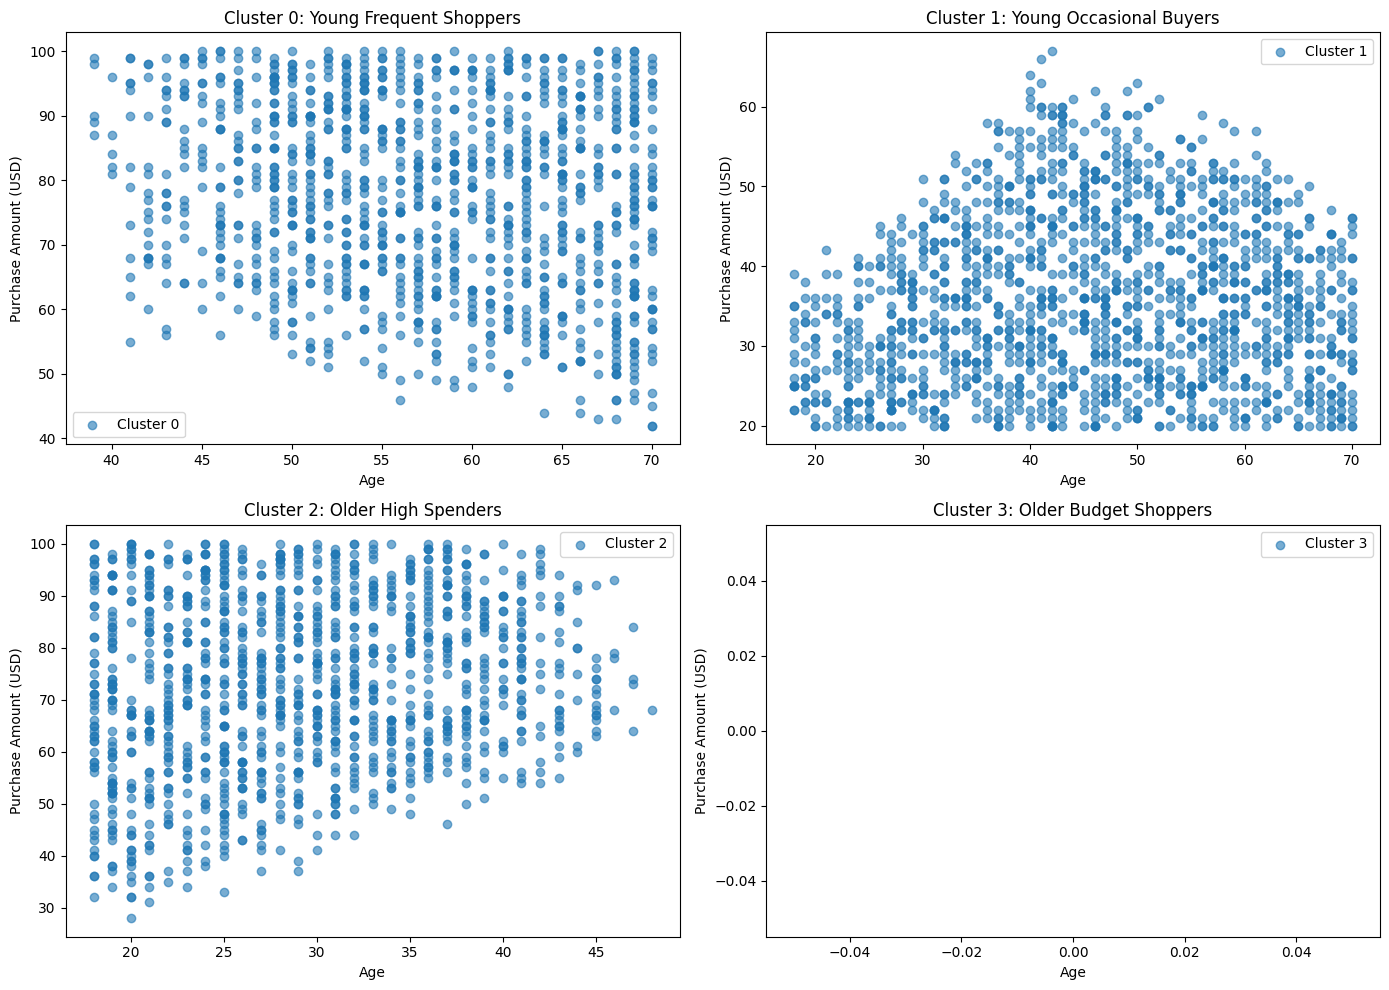

In [ ]:
import matplotlib.pyplot as plt

# Set up a 2x2 subplot grid for 4 clusters
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# List of cluster DataFrames and titles
clusters = [cluster_0, cluster_1, cluster_2, cluster_3]
titles = ["Cluster 0: Young Frequent Shoppers",
          "Cluster 1: Young Occasional Buyers",
          "Cluster 2: Older High Spenders",
          "Cluster 3: Older Budget Shoppers"]

# Plot each cluster
for i, cluster in enumerate(clusters):
    axes[i].scatter(cluster['Age'], cluster['Purchase Amount (USD)'],
                    alpha=0.6, label=f'Cluster {i}')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Purchase Amount (USD)")
    axes[i].legend()

plt.tight_layout()
plt.show()


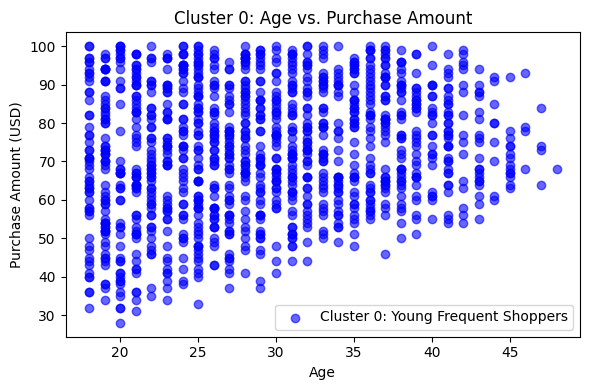

In [ ]:
import matplotlib.pyplot as plt

# Plot Cluster 0
plt.figure(figsize=(6, 4))
plt.scatter(cluster_2['Age'], cluster_2['Purchase Amount (USD)'],
            alpha=0.6, c='blue', label='Cluster 0: Young Frequent Shoppers')
plt.title("Cluster 0: Age vs. Purchase Amount")
plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Group by Cluster and Payment Method, then count
payment_by_cluster = df.groupby(['Cluster', 'Payment Method']).size().unstack().fillna(0)

# View the result
print(payment_by_cluster)


Payment Method  Bank Transfer  Cash  Credit Card  Debit Card  PayPal  Venmo
Cluster                                                                    
0                         176   187          204         179     184    226
1                         263   256          270         263     249    226
2                         193   205          222         191     205    201
